# NBA Breakout Analysis
**Author:** Mike Zhang  
**Date:** 2026-03-25  
**Purpose:** Identify players who broke out in the second half of seasons on non-playoff teams and examine whether their post all-star performance from the previous season predicts their following season performance

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import os
import statsmodels.api as sm    
import statsmodels.formula.api as smf
from adjustText import adjust_text
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.chdir(r'C:/Users/mikei/OneDrive/Desktop/Python/nba_breakout_analysis')

<Axes: xlabel='PIE_change', ylabel='PIE_diff'>

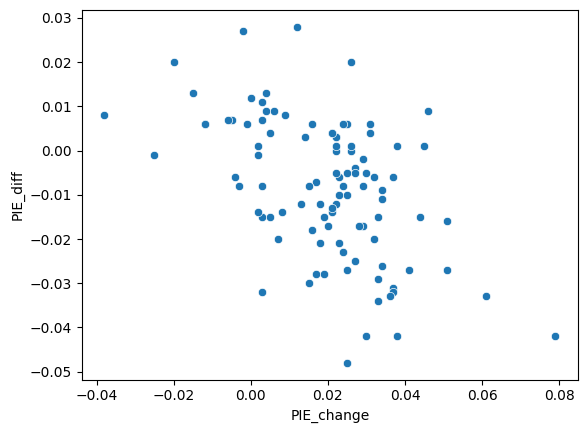

In [8]:
all_candidates = pd.read_csv('data/nba_breakout_candidates.csv')

sns.scatterplot(data = all_candidates, x='PIE_change', y='PIE_diff')

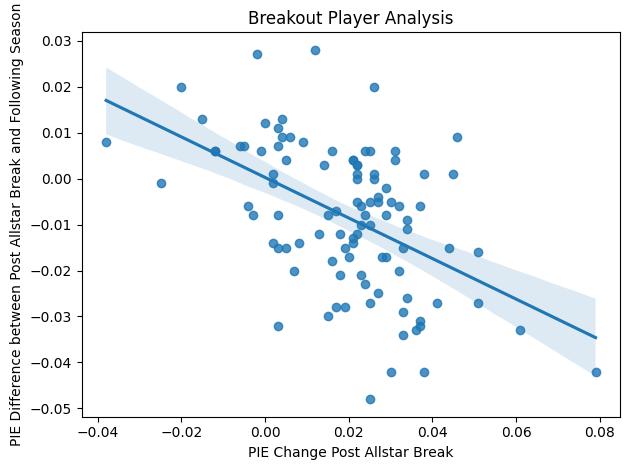

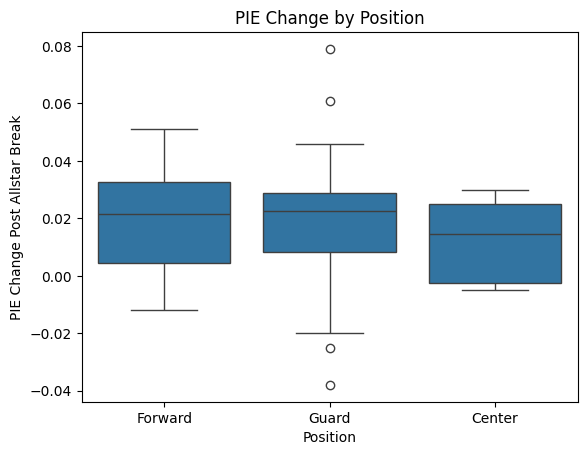

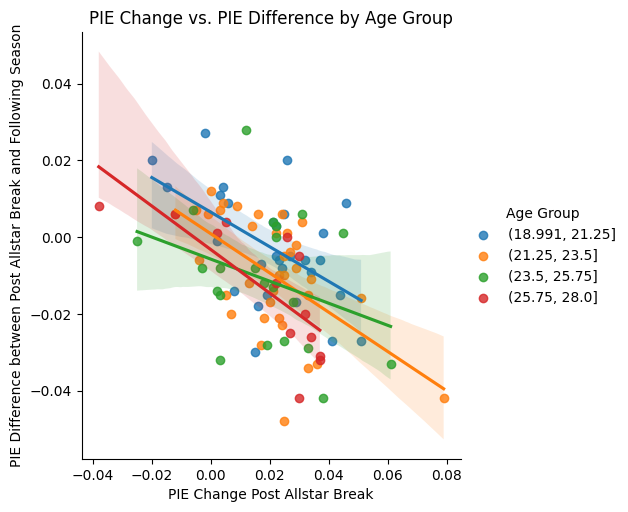

In [9]:
sns.regplot(data=all_candidates, x = 'PIE_change', y = 'PIE_diff')
plt.xlabel('PIE Change Post Allstar Break')
plt.ylabel('PIE Difference between Post Allstar Break and Following Season')
plt.title('Breakout Player Analysis')
plt.tight_layout()
plt.show()

sns.boxplot(data=all_candidates, x='POSITION_simplified', y='PIE_change')
plt.xlabel('Position')
plt.ylabel('PIE Change Post Allstar Break')
plt.title('PIE Change by Position')
plt.savefig('plots/position_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

all_candidates['AGE_bin'] = pd.cut(all_candidates['AGE_post'], bins=4)
sns.lmplot(data=all_candidates, x='PIE_change', y='PIE_diff', hue='AGE_bin').legend.set_title('Age Group')
plt.xlabel('PIE Change Post Allstar Break')
plt.ylabel('PIE Difference between Post Allstar Break and Following Season')
plt.title('PIE Change vs. PIE Difference by Age Group')
plt.savefig('plots/age_binned_regression.png', dpi=150, bbox_inches='tight')
plt.show()

<Axes: xlabel='PIE_diff', ylabel='Count'>

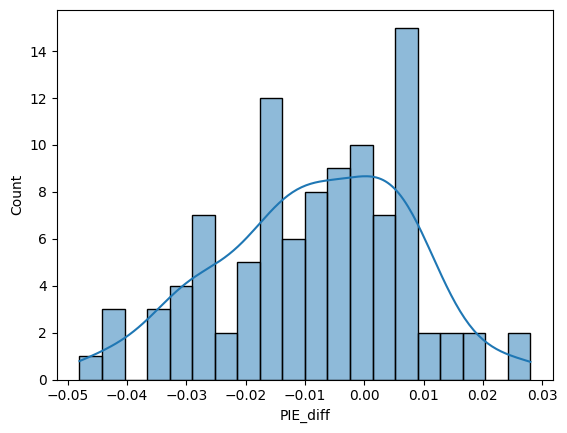

In [10]:
sns.histplot(data=all_candidates, x='PIE_diff', bins=20, kde=True)

In [11]:
def plot_diagnostics(model):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.scatterplot(y=model.resid, x=model.fittedvalues, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel('Fitted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted Values')
  
    sm.qqplot(model.resid, line='s', ax=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     6.111
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           5.03e-07
Time:                        10:50:25   Log-Likelihood:                 299.71
No. Observations:                 100   AIC:                            -577.4
Df Residuals:                      89   BIC:                            -548.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0356      0.021      1.733      0.087      -0.005       0.076
change_team[T.True]                  -0.0055      0.004     -1.541      0.127      -0.012       0.002
C(POSITION_simplified)[T.Forward]     0.0055      0.006      0.963      0.338      -0.006       0.017
C(POSITION_simplified)[T.Guard]       0.0053      0.006      0.959      0.340      -0.006       0.016
PIE_change                           -0.4977      0.077     -6.470      0.000      -0.651      -0.345
OVERALL_PICK                         -0.0001   8.12e-05     -1.317      0.191      -0.000    5.44e-05
PIE_pre                              -0.1332      0.072     -1.839      0.069      -0.277       0.011
USG_change                           -0.0024      0.059     -0.040      0.968      -0.119       0.114
AGE_post                             -0.0013      0.001     -1.859      0.066      -0.003    8.83e-05
MIN_post                              0.0002      0.000      0.319      0.750      -0.001       0.001
avg_wins_3yr                       2.722e-06      0.000      0.014      0.989      -0.000       0.000
==============================================================================
Omnibus:                        0.934   Durbin-Watson:                   2.143
Prob(Omnibus):                  0.627   Jarque-Bera (JB):                1.042
Skew:                           0.199   Prob(JB):                        0.594
Kurtosis:                       2.698   Cond. No.                     3.58e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.58e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,Variable,VIF
0,PIE_change,2.441639
1,PIE_pre,17.595716
2,USG_change,1.974009
3,OVERALL_PICK,3.256487
4,AGE_post,71.760666
5,MIN_post,67.858876
6,avg_wins_3yr,26.079138


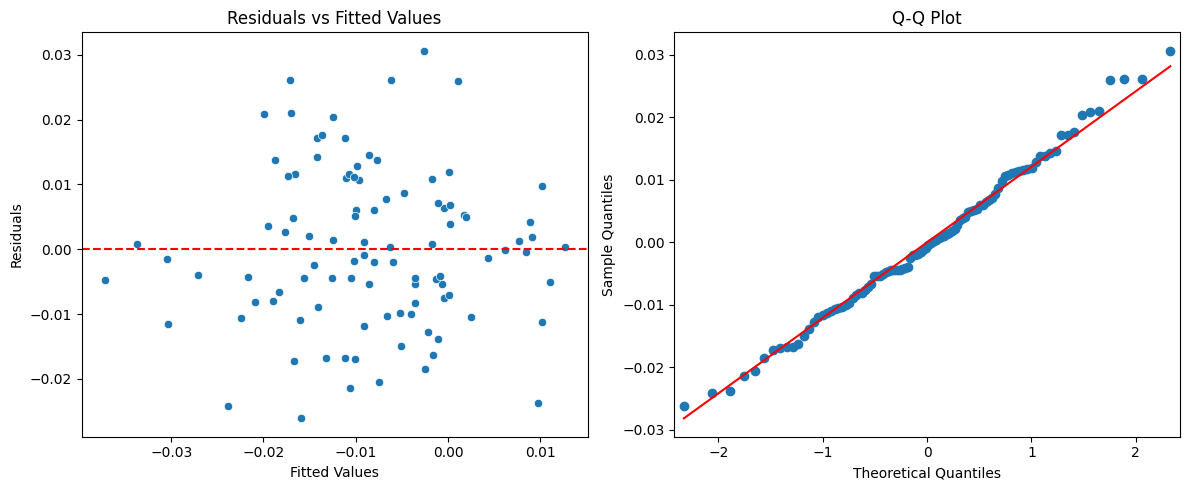

In [12]:
diff_model = smf.ols('PIE_diff ~ PIE_change + change_team + OVERALL_PICK + PIE_pre + USG_change + AGE_post + MIN_post + avg_wins_3yr + C(POSITION_simplified)', data=all_candidates).fit()
display(diff_model.summary())

# Diagnostic plots
plot_diagnostics(diff_model)

# Calculate VIF for multicollinearity
numerical_predictors = all_candidates[['PIE_change', 'PIE_pre', 'USG_change', 'OVERALL_PICK', 'AGE_post', 'MIN_post', 'avg_wins_3yr']]
vif = [variance_inflation_factor(numerical_predictors.values, i) for i in range(numerical_predictors.shape[1])]
vif_df = pd.DataFrame({'Variable': numerical_predictors.columns, 'VIF': vif})
vif_df

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     9.673
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.93e-08
Time:                        10:50:26   Log-Likelihood:                 297.82
No. Observations:                 100   AIC:                            -581.6
Df Residuals:                      93   BIC:                            -563.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0302      0.015      1.954      0.054      -0.000       0.061
change_team[T.True]                  -0.0054      0.003     -1.564      0.121      -0.012       0.001
C(POSITION_simplified)[T.Forward]     0.0093      0.005      1.781      0.078      -0.001       0.020
C(POSITION_simplified)[T.Guard]       0.0097      0.005      1.970      0.052    -7.9e-05       0.020
PIE_change                           -0.4968      0.074     -6.756      0.000      -0.643      -0.351
OVERALL_PICK                         -0.0001   7.87e-05     -1.331      0.186      -0.000    5.15e-05
AGE_post                             -0.0015      0.001     -2.211      0.029      -0.003      -0.000
==============================================================================
Omnibus:                        0.232   Durbin-Watson:                   2.136
Prob(Omnibus):                  0.890   Jarque-Bera (JB):                0.196
Skew:                           0.104   Prob(JB):                        0.907
Kurtosis:                       2.936   Cond. No.                     2.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,Variable,VIF
0,PIE_change,2.176893
1,AGE_post,4.558087
2,OVERALL_PICK,2.987781


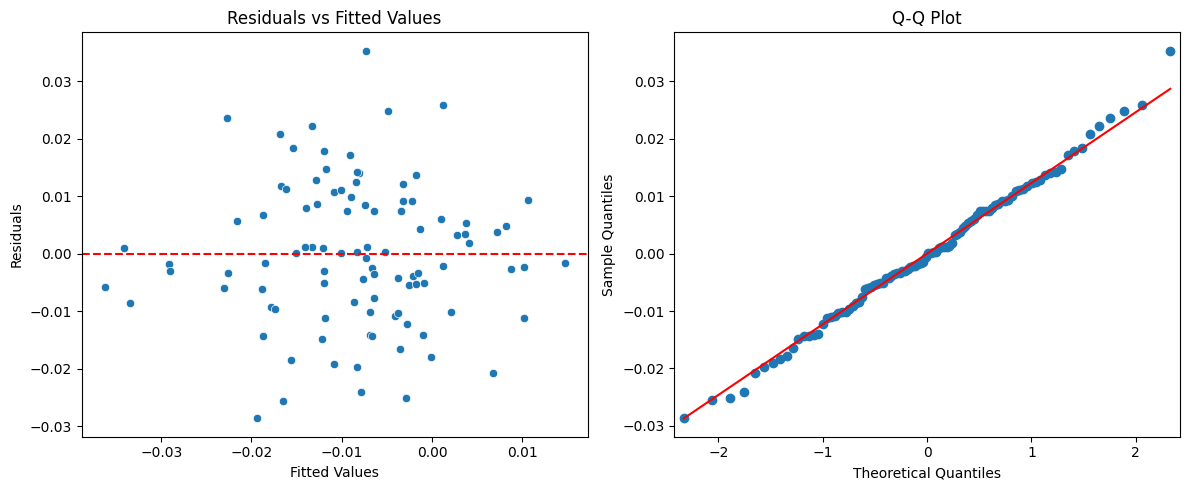

In [13]:
# Refine doff_model to address multicollinearity
diff_model = smf.ols('PIE_diff ~ PIE_change + OVERALL_PICK + AGE_post + change_team + C(POSITION_simplified)', data=all_candidates).fit()
display(diff_model.summary())

plot_diagnostics(diff_model)

numerical_predictors_reduced = all_candidates[['PIE_change', 'AGE_post', 'OVERALL_PICK']]
vif_reduced = [variance_inflation_factor(numerical_predictors_reduced.values, i) for i in range(numerical_predictors_reduced.shape[1])]
vif_reduced_df = pd.DataFrame({'Variable': numerical_predictors_reduced.columns, 'VIF': vif_reduced})
vif_reduced_df

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     13.26
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.27e-08
Time:                        10:50:27   Log-Likelihood:                 295.76
No. Observations:                 100   AIC:                            -581.5
Df Residuals:                      95   BIC:                            -568.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0425      0.014      2.979      0.004       0.014       0.071
C(POSITION_simplified)[T.Forward]     0.0081      0.005      1.556      0.123      -0.002       0.018
C(POSITION_simplified)[T.Guard]       0.0078      0.005      1.591      0.115      -0.002       0.017
PIE_change                           -0.4668      0.073     -6.424      0.000      -0.611      -0.323
AGE_post                             -0.0021      0.001     -3.608      0.000      -0.003      -0.001
==============================================================================
Omnibus:                        0.018   Durbin-Watson:                   2.099
Prob(Omnibus):                  0.991   Jarque-Bera (JB):                0.068
Skew:                           0.028   Prob(JB):                        0.967
Kurtosis:                       2.885   Cond. No.                     1.30e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.3e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

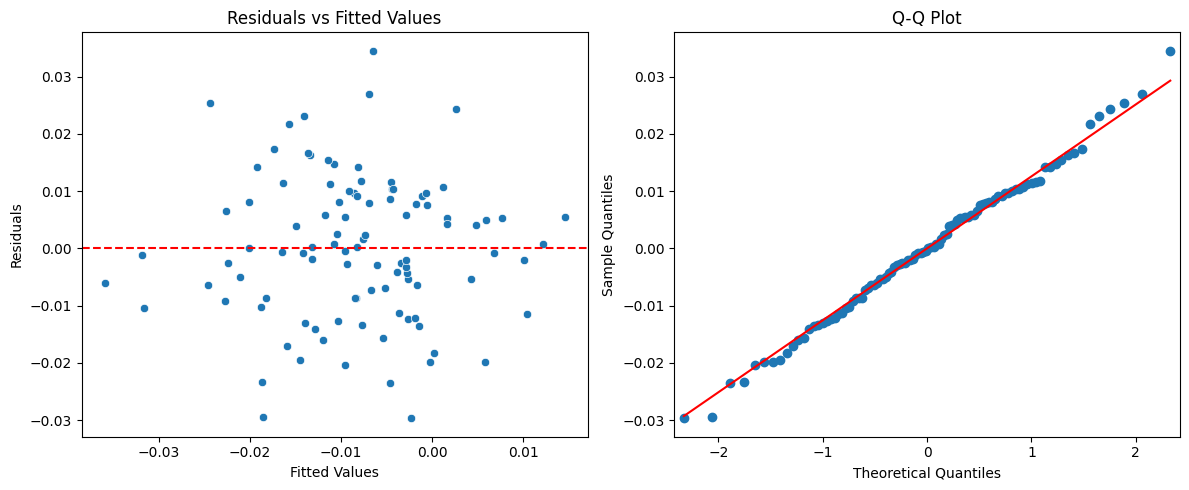

In [14]:
# Refine model again 
diff_model = smf.ols('PIE_diff ~ PIE_change + AGE_post + C(POSITION_simplified)', data=all_candidates).fit()
display(diff_model.summary())

plot_diagnostics(diff_model)
plt.savefig('plots/diff_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


8 influential points identified


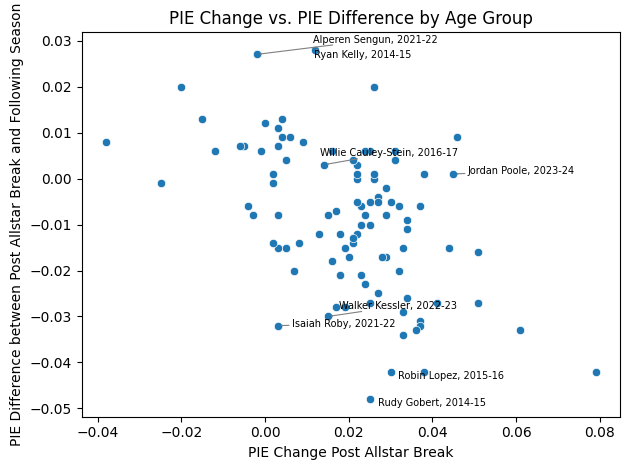

In [15]:
influence = diff_model.get_influence()
cooks = influence.cooks_distance[0]
all_candidates['cooks_d'] = cooks

threshold = 4 / len(all_candidates)
outliers = all_candidates[all_candidates['cooks_d'] > threshold]
print(f"{len(outliers)} influential points identified")

ax = sns.scatterplot(data=all_candidates, x='PIE_change', y='PIE_diff')

texts = []
for _, row in outliers.iterrows():
    texts.append(ax.text(
        row['PIE_change'], row['PIE_diff'],
        f"{row['PLAYER_NAME_post']}, {row['season']}",
        fontsize=7
    ))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
plt.xlabel('PIE Change Post Allstar Break')
plt.ylabel('PIE Difference between Post Allstar Break and Following Season')
plt.title('PIE Change vs. PIE Difference by Age Group')
plt.tight_layout()
plt.savefig('plots/outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


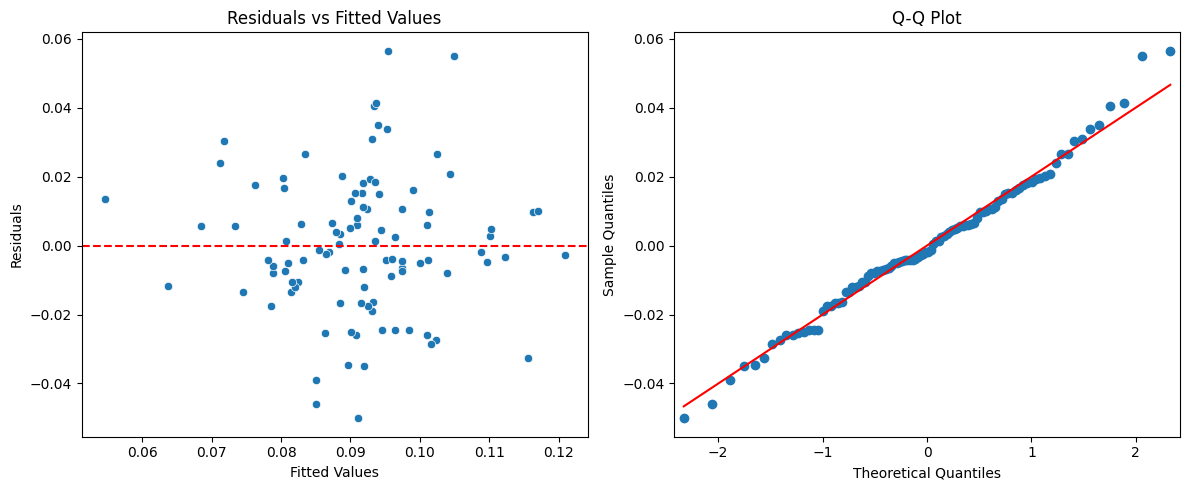

In [16]:
# Fit a secondary model 
following_model = smf.ols('PIE_following ~ PIE_change + AGE_post + C(POSITION_simplified)', data=all_candidates).fit()
following_model.summary()
 
plot_diagnostics(following_model)
plt.savefig('plots/following_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# Logisti Regression to predict breakout status
all_candidates['sustained'] = (all_candidates['PIE_diff'] >= 0).astype(int)
all_candidates['sustained'].value_counts()

all_candidates['PIE_change_scaled'] = all_candidates['PIE_change'] * 100

logit_model = smf.logit(
    'sustained ~ PIE_change_scaled + AGE_post + C(POSITION_simplified)',
    data=all_candidates
).fit()
display(logit_model.summary())

odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int().rename(columns={0: '2.5%', 1: '97.5%'}))
conf['OR'] = odds_ratios
print(conf)

Optimization terminated successfully.
         Current function value: 0.586806
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              sustained   No. Observations:                  100
Model:                          Logit   Df Residuals:                       95
Method:                           MLE   Df Model:                            4
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.1095
Time:                        10:50:29   Log-Likelihood:                -58.681
converged:                       True   LL-Null:                       -65.896
Covariance Type:            nonrobust   LLR p-value:                  0.006042
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             2.4886      2.541      0.980      0.327      -2.491       7.468
C(POSITION_simplified)[T.Forward]     0.4240      0.898      0.472      0.637      -1.337       2.185
C(POSITION_simplified)[T.Guard]       0.3731      0.842      0.443      0.658      -1.278       2.024
PIE_change_scaled                    -0.4903      0.147     -3.335      0.001      -0.779      -0.202
AGE_post                             -0.1100      0.108     -1.018      0.309      -0.322       0.102
=====================================================================================================
"""

                                       2.5%        97.5%         OR
Intercept                          0.082834  1751.391051  12.044664
C(POSITION_simplified)[T.Forward]  0.262643     8.890508   1.528079
C(POSITION_simplified)[T.Guard]    0.278677     7.567172   1.452169
PIE_change_scaled                  0.459079     0.816982   0.612421
AGE_post                           0.724885     1.107103   0.895836


In [18]:
# Save models using pickle

with open('models/diff_model.pkl', 'wb') as f:
    pickle.dump(diff_model, f)

with open('models/following_model.pkl', 'wb') as f:
    pickle.dump(following_model, f)

with open('models/logit_model.pkl', 'wb') as f:
    pickle.dump(logit_model, f)